# Round 005 — ตระกูล E: ตัวคุมความเสี่ยงระดับตลาด

**ทำอะไร:** ถือตลาด (SPY หรือ EW) แต่หนีไปถือเงินสดเมื่อ trend ขาลง / ความผันผวนสูง / drawdown ลึก

**อุปมา:** เหมือนร่มที่กางเมื่อฝนตก — ช่วยไม่ให้เปียก แต่ถ้าฝนตกสั้น ๆ แล้วหยุด การกาง-หุบร่มช้าไปหนึ่งจังหวะก็ทำให้เสียเวลา

**อ่านผลอย่างไร:** ดูทั้งตารางช่วงตัดสินและตาราง S5 (ประวัติยาว 6 ดัชนี) — สเปกใน rounds/round_005/HYPOTHESIS.md

In [1]:
import sys, pathlib; sys.path.insert(0, str(pathlib.Path.cwd().parent))
import pandas as pd
from IPython.display import Image, Markdown, display
from lib import report
report.banner()
r = pd.read_csv("../rounds/round_005/results.csv")
cols = [c for c in ["trial_id","dec_sharpe","dec_sharpe_ew","dec_sharpe_spy","dec_cagr","dec_cagr_ew","dec_maxdd","dec_maxdd_ew",
        "S1_10","S1_25","S2_share","DSR","S6_avg_n","S6_min_n","info_sharpe","info_sharpe_ew"] if c in r.columns]
pd.set_option("display.width", 250); pd.set_option("display.max_rows", 200)
display(r[cols].round(3))
ok = lambda c: r[c].astype(str).str.lower().eq("true")
print("ผู้เข้ารอบ (S1+S2+S3+S6):", list(r[ok("S1") & ok("S2") & ok("S3") & ok("S6")].trial_id))


> ⚠️ **คำเตือน survivorship bias (แสดงในทุก notebook)**
> รายชื่อสมาชิกมาจาก fja05680/sp500 (point-in-time) แต่ **ราคามาจาก yfinance ซึ่งเก็บเฉพาะหุ้นที่ยังซื้อขายอยู่**
> หุ้นที่ถูกซื้อกิจการ/ล้มละลาย/เปลี่ยนชื่อจำนวนหนึ่งจึงไม่มีราคา และหลุดออกจาก backtest
> ผลตอบแทนที่คำนวณได้จึงมีแนวโน้ม **สูงกว่าความจริง** (หุ้นที่ "ตาย" ไปมักเป็นหุ้นที่ผลตอบแทนแย่)
> สัดส่วนที่ขาดหายวัดไว้ใน `v0_data_audit.ipynb`

> ⚠️ **ข้อจำกัดของ held-out**: held-out = rebalance มิ.ย. 2023, 2024, 2025 (3 รอบเต็ม) + มิ.ย. 2026 ที่ถือได้แค่ ~3 เดือน
> (รอบ 2026 เป็นข้อมูลประกอบ ไม่นับตัดสิน) — มีแค่ 2–3 รอบ rebalance ที่ใช้ตัดสิน ผลช่วงนี้จึงมีความไม่แน่นอนสูงมาก
> ใช้เป็นการตรวจทิศทางเท่านั้น ไม่ใช่หลักฐานทางสถิติ


,trial_id,dec_sharpe,dec_sharpe_ew,dec_sharpe_spy,dec_cagr,dec_cagr_ew,dec_maxdd,dec_maxdd_ew,S1_10,S1_25,S2_share,DSR,S6_avg_n,S6_min_n,info_sharpe,info_sharpe_ew
0,r005_trend_SPY,0.457,0.614,0.681,0.068,0.122,-0.249,-0.384,False,False,0.054,0.0,415.069,0,0.993,1.093
1,r005_voltarget_SPY,0.592,0.614,0.681,0.091,0.122,-0.322,-0.384,False,False,0.000,0.0,502.319,497,1.130,1.093
2,r005_ddstop_SPY,0.486,0.614,0.681,0.081,0.122,-0.337,-0.384,False,False,0.000,0.0,481.389,0,1.027,1.093
3,r005_trend_EW,0.369,0.614,0.681,0.058,0.122,-0.235,-0.384,False,False,0.027,0.0,265.562,0,1.098,1.093
4,r005_voltarget_EW,0.451,0.614,0.681,0.077,0.122,-0.376,-0.384,False,False,0.000,0.0,323.049,255,0.989,1.093
5,r005_ddstop_EW,0.347,0.614,0.681,0.063,0.122,-0.384,-0.384,False,False,0.000,0.0,315.382,0,1.093,1.093


ผู้เข้ารอบ (S1+S2+S3+S6): []


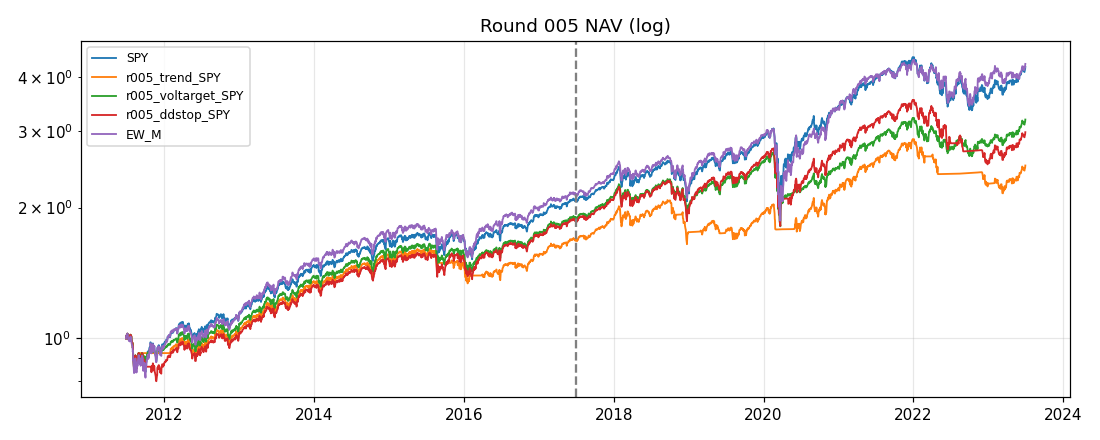

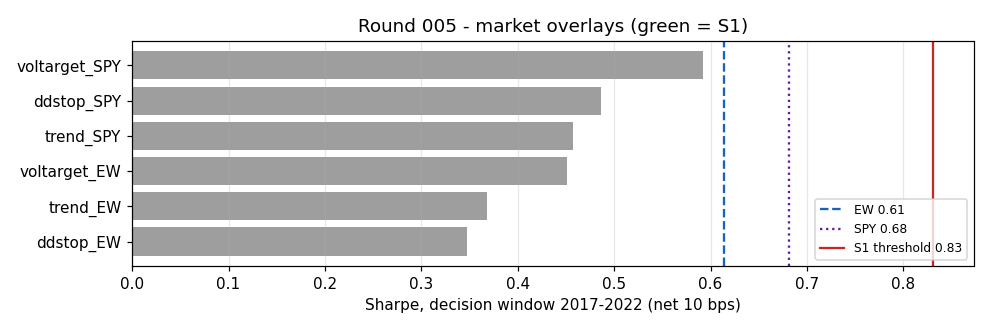

In [2]:
for f in sorted(pathlib.Path("../figures").glob("round_005_*.png")): display(Image(filename=str(f)))

In [3]:
display(Markdown(pathlib.Path("../rounds/round_005/RESULTS.md").read_text()))

# Round 005 — ผล (ตระกูล E: ตัวคุมความเสี่ยงระดับตลาด) — **ไม่มีผู้เข้ารอบ**

- trial รอบนี้ 6 → สะสม **91**; ตาราง `results.csv`, ด่าน S5 บนดัชนี 6 ชุด `s5_indices.csv`
- benchmark ช่วงตัดสิน: EW(U) รายเดือน 0.614 · SPY 0.681

| ผลสำคัญ | ตัวเลข |
|---|---|
| ช่วงตัดสิน 2017–2022 | ทุก overlay **แพ้ทั้ง SPY และ EW**: Sharpe 0.347–0.592, CAGR 5.8–9.1% (SPY buy-and-hold ~12.5%) |
| drawdown | trend ลด MaxDD ได้ (SPY: −24.9%; EW: −23.5% vs EW −38.4%) แต่แลกด้วยผลตอบแทนที่ต่ำมาก |
| S6 | trend/ddstop ตก (มีเดือนถือเงินสด 100%: 17.4% และ 4.2% ของเดือนสำหรับ SPY) |
| **S5 ประวัติยาว/ตลาดอื่น** | overlay ดีกว่า buy-and-hold 4–5 จาก 6 ดัชนี (เช่น ^GSPC 1970–2010 trend 0.600 vs 0.456) |

## การตีความ
- ตัวคุมความเสี่ยงช่วยปรับ Sharpe ได้ใน "ประวัติยาว" หลายตลาด แต่ในช่วง 2017–2022 (crash สั้นแล้วฟื้นเร็ว) มันออกช้าเข้าช้า → ต้นทุนโอกาสสูง
- เป็นเครื่องมือลดความเสี่ยง ไม่ใช่เครื่องมือ "ชนะตลาดขาดรอย" ตามเกณฑ์ S1 — ผลลบในช่วง design
